# Identifying Hidden Value NBA Players Using Python

### Author: Kyle Tokishi  
### Tools: Python, Pandas, Matplotlib, Seaborn  
### Dataset: NBA Player Game Stats 2024–2025

## Project Overview

NBA teams often rely on star players who receive the majority of playing time. However, some players may produce a strong impact in limited minutes but remain underutilized in team rotations.

This analysis aims to identify players who generate high per-minute value despite averaging fewer than 20 minutes per game.


## 1. Import Python Libraries

The following libraries are used for data analysis and visualization:

- Pandas for data manipulation
- Matplotlib and Seaborn for visualizations


In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


## 2. Load Dataset

The dataset contains individual NBA player game performances from the 2024–2025 season.

Each row represents a player's performance in a single game and includes statistics such as:

- Minutes played
- Points
- Assists
- Rebounds
- Game Score (overall impact metric)


In [69]:
df = pd.read_csv("database_24_25.csv")

df.head()

,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Data
0,Jayson Tatum,BOS,NYK,W,30.30,14,18,0.778,8,11,...,4,4,10,1,1,1,1,37,38.1,2024-10-22
1,Anthony Davis,LAL,MIN,W,37.58,11,23,0.478,1,3,...,13,16,4,1,3,1,1,36,34.0,2024-10-22
2,Derrick White,BOS,NYK,W,26.63,8,13,0.615,6,10,...,3,3,4,1,0,0,1,24,22.4,2024-10-22
3,Jrue Holiday,BOS,NYK,W,30.52,7,9,0.778,4,6,...,2,4,4,1,0,0,2,18,19.5,2024-10-22
4,Miles McBride,NYK,BOS,L,25.85,8,10,0.800,4,5,...,0,0,2,0,0,1,1,22,17.8,2024-10-22


## 3. Data Exploration

Before performing the analysis, the structure of the dataset was analyzed.

The following steps inspect:

- data types
- number of observations
- summary statistics


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  16512 non-null  object 
 1   Tm      16512 non-null  object 
 2   Opp     16512 non-null  object 
 3   Res     16512 non-null  object 
 4   MP      16512 non-null  float64
 5   FG      16512 non-null  int64  
 6   FGA     16512 non-null  int64  
 7   FG%     16512 non-null  float64
 8   3P      16512 non-null  int64  
 9   3PA     16512 non-null  int64  
 10  3P%     16512 non-null  float64
 11  FT      16512 non-null  int64  
 12  FTA     16512 non-null  int64  
 13  FT%     16512 non-null  float64
 14  ORB     16512 non-null  int64  
 15  DRB     16512 non-null  int64  
 16  TRB     16512 non-null  int64  
 17  AST     16512 non-null  int64  
 18  STL     16512 non-null  int64  
 19  BLK     16512 non-null  int64  
 20  TOV     16512 non-null  int64  
 21  PF      16512 non-null  int64  
 22

In [71]:
df.describe()

,MP,FG,FGA,FG%,3P,3PA,3P%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,22.405259,3.848958,8.271742,0.427527,1.250061,3.477955,0.263719,1.572917,2.016897,0.417737,1.027253,3.071827,4.099079,2.453852,0.769985,0.468084,1.273861,1.749152,10.520894,8.575109
std,10.896645,3.255864,6.071434,0.254938,1.523651,3.151726,0.286271,2.233374,2.688863,0.435771,1.371552,2.717525,3.478652,2.613505,0.991039,0.833377,1.428819,1.436416,8.829493,7.821577
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-7.600000
25%,14.427500,1.000000,4.000000,0.286000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,3.000000,2.400000
50%,23.430000,3.000000,7.000000,0.444000,1.000000,3.000000,0.250000,1.000000,1.000000,0.333000,1.000000,2.000000,3.000000,2.000000,0.000000,0.000000,1.000000,2.000000,9.000000,7.100000
75%,31.322500,6.000000,12.000000,0.571000,2.000000,5.000000,0.500000,2.000000,3.000000,1.000000,2.000000,4.000000,6.000000,4.000000,1.000000,1.000000,2.000000,3.000000,16.000000,13.300000
max,50.480000,22.000000,38.000000,1.000000,10.000000,20.000000,1.000000,18.000000,26.000000,1.000000,12.000000,23.000000,28.000000,22.000000,8.000000,10.000000,11.000000,6.000000,60.000000,54.200000


## 4. Feature Engineering: Per-Minute Efficiency Metrics

To fairly compare players with different playing time, per-minute efficiency metrics were created.

These metrics normalize production relative to playing time.

Metrics created:

- Points per minute
- Assists per minute
- Rebounds per minute
- Game Score per minute


In [72]:
df["PTS_per_min"] = df["PTS"] / df["MP"]
df["AST_per_min"] = df["AST"] / df["MP"]
df["REB_per_min"] = df["TRB"] / df["MP"]
df["GmSc_per_min"] = df["GmSc"] / df["MP"]

df.head()

,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,...,BLK,TOV,PF,PTS,GmSc,Data,PTS_per_min,AST_per_min,REB_per_min,GmSc_per_min
0,Jayson Tatum,BOS,NYK,W,30.30,14,18,0.778,8,11,...,1,1,1,37,38.1,2024-10-22,1.221122,0.330033,0.132013,1.257426
1,Anthony Davis,LAL,MIN,W,37.58,11,23,0.478,1,3,...,3,1,1,36,34.0,2024-10-22,0.957956,0.106440,0.425758,0.904737
2,Derrick White,BOS,NYK,W,26.63,8,13,0.615,6,10,...,0,0,1,24,22.4,2024-10-22,0.901239,0.150207,0.112655,0.841157
3,Jrue Holiday,BOS,NYK,W,30.52,7,9,0.778,4,6,...,0,0,2,18,19.5,2024-10-22,0.589777,0.131062,0.131062,0.638925
4,Miles McBride,NYK,BOS,L,25.85,8,10,0.800,4,5,...,0,1,1,22,17.8,2024-10-22,0.851064,0.077369,0.000000,0.688588


## 5. Aggregating Player Performance

The dataset contains game-level observations where each row represents a player's performance in a single game.

To evaluate overall player efficiency across the season, statistics were aggregated by player. This produces average values for each player's minutes played and efficiency metrics.


In [73]:
player_stats = df.groupby("Player").agg({
    "MP": "mean",
    "PTS_per_min": "mean",
    "AST_per_min": "mean",
    "REB_per_min": "mean",
    "GmSc_per_min": "mean",
    "PTS": "mean"
}).reset_index()

player_stats.rename(columns={"MP": "avg_minutes"}, inplace=True)

player_stats.head()


,Player,avg_minutes,PTS_per_min,AST_per_min,REB_per_min,GmSc_per_min,PTS
0,A.J. Green,21.997500,0.343601,0.058662,0.099650,0.243488,7.659091
1,A.J. Lawson,3.757500,0.805603,0.000000,0.154243,0.527194,2.750000
2,AJ Johnson,6.022222,0.369160,0.179436,0.231537,0.097166,2.444444
3,Aaron Gordon,26.666000,0.469476,0.118732,0.166057,0.391643,12.333333
4,Aaron Holiday,11.371944,0.380521,0.110747,0.083226,0.276438,4.222222


## 6. Creating the Hidden Value Score

To evaluate overall player impact, a composite metric called the **Hidden Value Score** was created.

This score combines several per-minute efficiency metrics:

• Points per minute  
• Assists per minute  
• Rebounds per minute  
• Game Score per minute  

By combining these metrics into a single value, we can compare players based on their overall production relative to playing time.


In [74]:
player_stats["Hidden_Value_Score"] = (
    player_stats["PTS_per_min"] * 0.4 +
    player_stats["AST_per_min"] * 0.2 +
    player_stats["REB_per_min"] * 0.2 +
    player_stats["GmSc_per_min"] * 0.2
)


## 7. Identifying Hidden Value Players

To identify potentially underutilized players, the analysis focuses on players averaging **10 - 20 minutes per game**.

Players in this range receive limited playing time but still participate regularly in team rotations. These players are then ranked according to their Hidden Value Score to highlight high-impact contributors.


In [75]:
hidden_value_players = player_stats[
    (player_stats["avg_minutes"] < 20) &
    (player_stats["avg_minutes"] >= 10)
]

hidden_value_players = hidden_value_players.sort_values(
    "Hidden_Value_Score",
    ascending=False
)

hidden_value_players.head(15)


,Player,avg_minutes,PTS_per_min,AST_per_min,REB_per_min,GmSc_per_min,PTS,Hidden_Value_Score
399,Moritz Wagner,18.804333,0.664900,0.071549,0.255299,0.499087,12.866667,0.431147
107,Daeqwon Plowden,16.360000,0.710910,0.000000,0.146142,0.577876,12.000000,0.429167
283,Jonas Valančiūnas,19.997000,0.560035,0.111106,0.404687,0.508296,11.400000,0.428832
234,Jalen Smith,15.334681,0.552913,0.059328,0.366554,0.489920,8.446809,0.404326
50,Bones Hyland,11.095000,0.660319,0.114621,0.115617,0.438354,7.200000,0.397846
83,Chris Boucher,17.343182,0.608751,0.033564,0.241421,0.488915,10.522727,0.396280
527,Ty Jerome,19.016327,0.567798,0.179533,0.131477,0.497739,11.285714,0.388869
246,Jared Butler,11.310937,0.555203,0.256374,0.092335,0.450857,6.875000,0.381994
491,T.J. McConnell,18.620612,0.508184,0.248899,0.144573,0.465752,9.836735,0.375118
117,Dante Exum,18.652500,0.586387,0.167252,0.072083,0.427818,11.500000,0.367985


## 8. Top Hidden Value Players

The following table shows the players with the highest Hidden Value Score among those averaging between 10 and 20 minutes per game.

These players demonstrate strong per-minute production despite limited playing time.


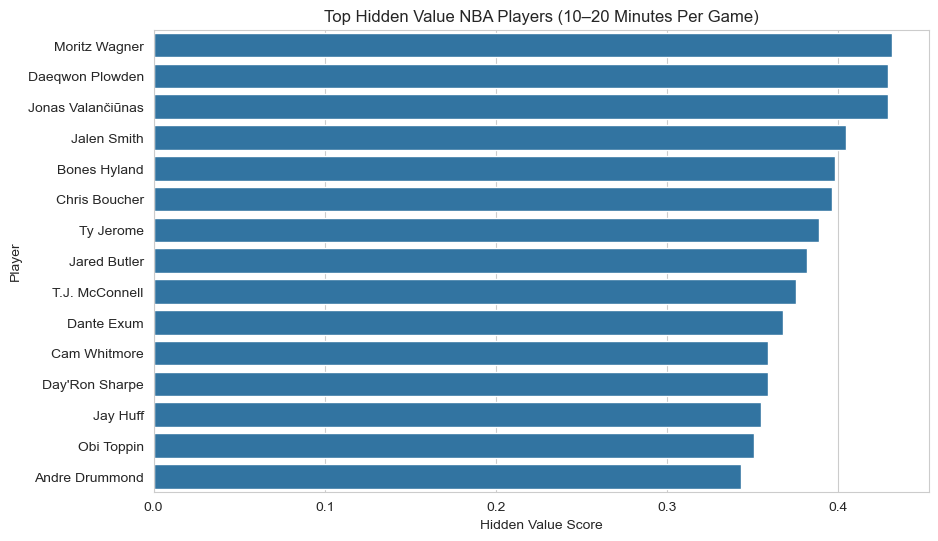

In [76]:
top_hidden = hidden_value_players.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Hidden_Value_Score",
    y="Player",
    data=top_hidden
)

plt.title("Top Hidden Value NBA Players (10–20 Minutes Per Game)")
plt.xlabel("Hidden Value Score")
plt.ylabel("Player")

plt.show()


## 9. Hidden Value Discovery Map

This visualization highlights the region where hidden value players are most likely to appear.

The vertical line represents the limited playing time threshold, while the horizontal line marks the top quartile of Hidden Value Scores. Players located in the upper-left quadrant represent high-impact contributors who may be underutilized.


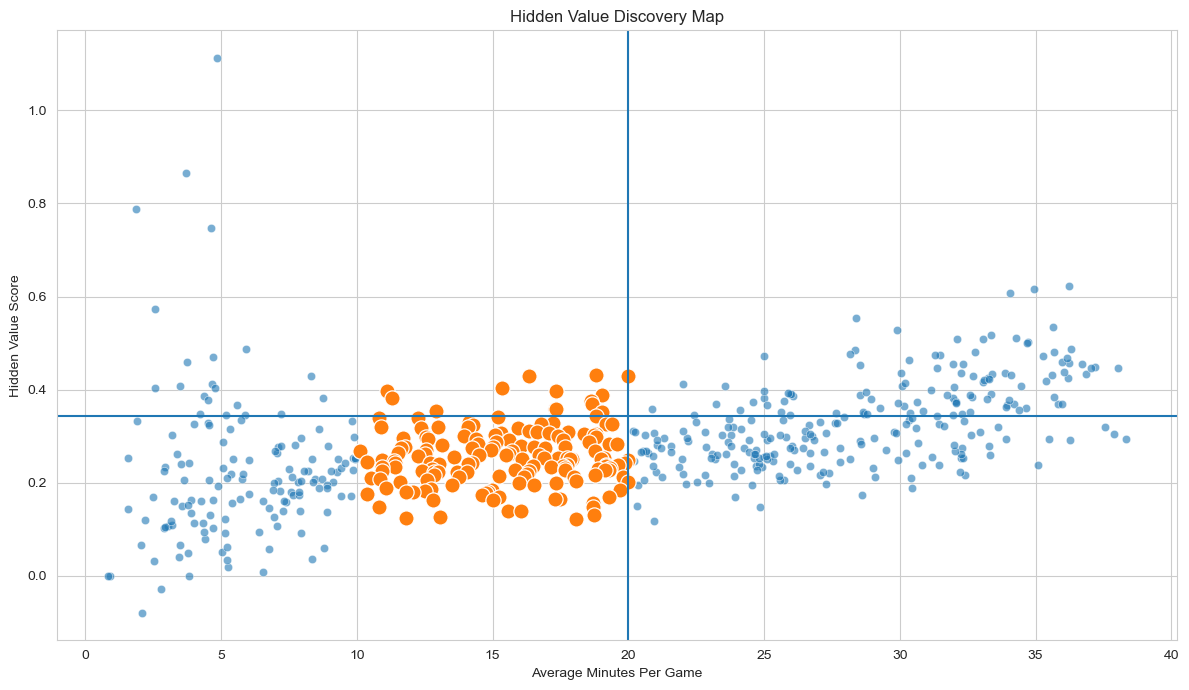

In [77]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    x="avg_minutes",
    y="Hidden_Value_Score",
    data=player_stats,
    alpha=0.6
)

sns.scatterplot(
    x="avg_minutes",
    y="Hidden_Value_Score",
    data=hidden_value_players,
    s=120
)

plt.axvline(20)
plt.axhline(player_stats["Hidden_Value_Score"].quantile(0.75))

plt.title("Hidden Value Discovery Map")
plt.xlabel("Average Minutes Per Game")
plt.ylabel("Hidden Value Score")

plt.tight_layout()
plt.show()


11. Key Insights

The analysis reveals that several players averaging 10 to 20 minutes per game produce efficiency levels comparable to, or higher than, many players receiving greater playing time. These players appear in the high efficiency, limited minutes region of the discovery map, indicating strong production relative to their opportunities.

The results demonstrate that playing time alone does not necessarily reflect player impact. While starters receive the majority of minutes, some rotational players generate similar or greater efficiency when performance is evaluated on a per minute basis. This suggests that roster roles and coaching strategies strongly influence player opportunity.

Identifying these high impact rotational players can provide teams with valuable insights. Increasing the playing time of highly efficient bench contributors may improve overall team productivity without requiring roster changes.

Conclusion

By constructing a Hidden Value Score based on per minute efficiency metrics, this project identified players who generate strong impact despite limited playing time.

This analysis demonstrates how data driven methods can uncover hidden value within NBA team rotations, highlighting players whose contributions may be greater than their current roles suggest.